      aluno  prova1  prova2  trabalho  frequencia
0       Ana     8.0     7.5       9.0          92
1     Bruno     6.5     7.0       8.0          81
2     Carla     9.5     8.5       9.0          96
3     Diego     5.0     6.0       7.5          74
4     Elisa     7.0     8.0       6.5          88
5     Fabio     4.5     5.5       6.0          69
6  Gabriela     8.5     9.0       7.5          90
7  Henrique     7.5     6.5       8.0          77
[8.1  7.15 8.95 6.15 7.25 5.35 8.4  7.25]
0         Ana
1       Bruno
2       Carla
4       Elisa
6    Gabriela
7    Henrique
Name: aluno, dtype: str


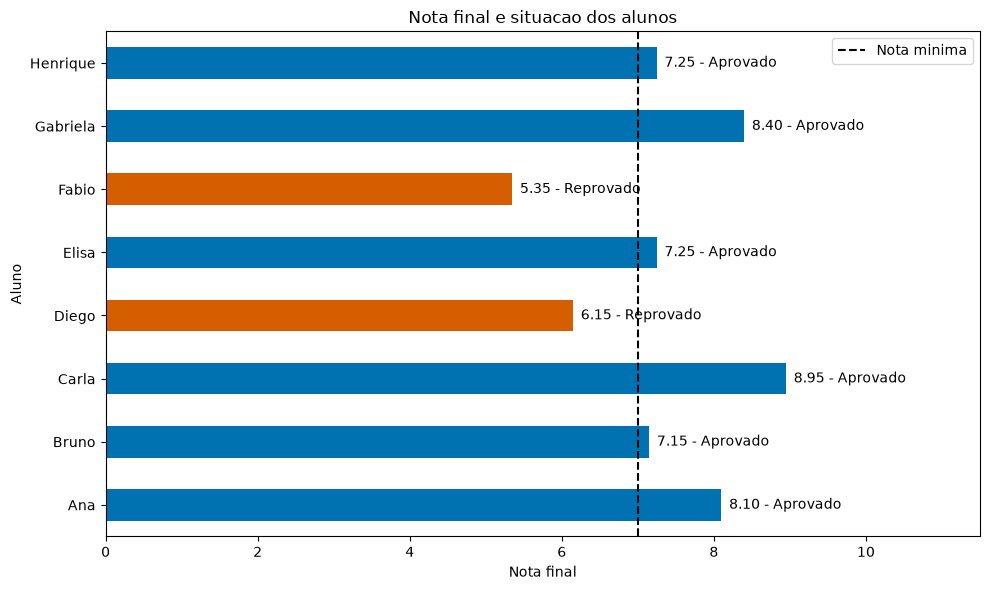

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("exercicios_csv/notas_alunos.csv")
print(df.head(n=10))
notas = df[["prova1", "prova2", "trabalho"]].to_numpy()
pesos = np.array([0.30, 0.40, 0.30])
nota_final = np.dot(notas, pesos)
print(nota_final)
df["nota_final"] = nota_final
df["situacao"] = np.where(
    (df["nota_final"] >= 7) & (df["frequencia"] >= 75),
    "Aprovado",
    "Reprovado",
)
aprovados = df[df["situacao"] == "Aprovado"]
print(aprovados["aluno"])

cores = df["situacao"].map({
    "Aprovado": "#0072B2",
    "Reprovado": "#D55E00",
})

ax = df.plot.barh(
    x="aluno",
    y="nota_final",
    color=cores,
    figsize=(10, 6),
    legend=False,
)

linha_minima = ax.axvline(
    7, color="black", linestyle="--", label="Nota minima"
)

for barra, situacao in zip(ax.patches, df["situacao"]):
    ax.text(
        barra.get_width() + 0.1,
        barra.get_y() + barra.get_height() / 2,
        f"{barra.get_width():.2f} - {situacao}",
        va="center",
    )

ax.set_title("Nota final e situacao dos alunos")
ax.set_xlabel("Nota final")
ax.set_ylabel("Aluno")
ax.set_xlim(0, 11.5)
ax.legend(handles=[linha_minima])
plt.tight_layout()
plt.show()

